<big>Nota Importante:</big>
Sobre la organización del codigo, primero decidi hacer el analisis de red por regio en la parte final del notebook se encuentra la sección 6 del proyecto

In [1]:
#Importo las distintas paqueterias
import numpy as np
import pandas as pd
import networkx as nx
import itertools
import matplotlib.pyplot as plt

In [2]:
data = 'srep00196-s3.csv'

#Encuentro la fila con mas columnas
with open(data) as f:
    max_cols = max(len(line.split(',')) for line in f)
#Creo un array con la longitud de las columnas maximas
cols = range(max_cols)

#Abro el csv con ese numero de columnas
df_raw = pd.read_csv(data, names=cols, engine='python')

#Solo tomo los datos que me importas
df = df_raw[df_raw[0].isin(['African', 'LatinAmerican'])].copy()


# Region de Africa

In [3]:
df_afr = df[df[0] == 'African']
df_afr

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,African,chicken,cinnamon,soy_sauce,onion,ginger,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,African,cane_molasses,ginger,cumin,garlic,tamarind,bread,coriander,vinegar,onion,...,None,None,None,None,None,None,None,None,None,None
2,African,butter,pepper,onion,cardamom,cayenne,ginger,cottage_cheese,garlic,brassica,...,None,None,None,None,None,None,None,None,None,None
3,African,olive_oil,pepper,wheat,beef,onion,cardamom,cumin,garlic,rice,...,None,None,None,None,None,None,None,None,None,None
4,African,honey,wheat,yeast,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,African,tomato,cayenne,onion,peanut,black_pepper,ginger,scallion,garlic,bell_pepper,...,None,None,None,None,None,None,None,None,None,None
348,African,vinegar,turnip,mustard,onion,black_pepper,bacon,cayenne,None,None,...,None,None,None,None,None,None,None,None,None,None
349,African,olive_oil,wheat,beef,shallot,cayenne,cumin,ginger,carrot,nutmeg,...,None,None,None,None,None,None,None,None,None,None
350,African,wheat,apricot,almond,walnut,cinnamon,date,vegetable_oil,egg,sesame_seed,...,None,None,None,None,None,None,None,None,None,None


In [4]:
#Creo una funcion que me haga el dataframe a una Grafo
def df_to_graph(df):
    #Creo un grafo vacio
    G = nx.Graph()
    #itero sobre las filas
    for _, fila in df.iterrows():
        #Hago una lista de ingredientes (Elimino la primera columna del dataset que representa la region)
        ingredientes = fila[1:].dropna().to_list()
        #Tomo todas las posibles combinaciones
        for (a,b) in itertools.combinations(ingredientes,2):
            #Verifico si ya tenian una aristas y si si la tiene le agrego uno al peso
            if G.has_edge(a,b):
                G[a][b]['weight'] +=1
            else:
                G.add_edge(a,b, weight = 1)
    return G

In [5]:
G_afr = df_to_graph(df_afr)

## 1. Descripción general de los datos:

Número de recetas por región.

Número de ingredientes distintos.

Tamaño promedio de las recetas.

Ingredientes más frecuentes por región.

In [6]:
#Funcion que hace la descripción General
def general_description(df,G):
    print("Numero de Recetas:", df.shape[0])
    print('Numero de ingredientes distintos:', nx.number_of_nodes(G))
    #Saco el tamaño promedio de las recestas
    num_ing = np.zeros(df.shape[0])
    tmp = 0
    dict_ing = {}
    for _,fila in df.iterrows():
        ings = fila[1:].dropna().to_list()
        ning = len(ings)
        num_ing[tmp] = ning
        tmp += 1
        for ing in ings:
            if ing in dict_ing.keys():
                dict_ing[ing] += 1
            else:
                dict_ing[ing] =1
    #Ordeno mi diccionario
    dict_ing = dict(sorted(dict_ing.items(), key=lambda item: item[1],reverse = True))

    print('Tamaño promedio de las recetas:', np.mean(num_ing))
    print('Ingredientes mas frecuentes por region:', list(dict_ing.keys())[0:5])

In [7]:
general_description(df_afr,G_afr)

Numero de Recetas: 352
Numero de ingredientes distintos: 197
Tamaño promedio de las recetas: 10.451704545454545
Ingredientes mas frecuentes por region: ['olive_oil', 'onion', 'cumin', 'garlic', 'cayenne']


## 2. Propiedades básicas de las redes:
 
Número de nodos y aristas.

Densidad.

Componentes conexas.

Tamaño de la componente gigante.

Grado promedio.

Distribución de grados.

Coeficiente de clustering.

Distancia promedio y diámetro, si la red lo permite.

In [8]:
#Funcion que me hace la descripcion del Grafo
def graph_description(G):
    print('Numero de nodos:',nx.number_of_nodes(G))
    print("Numero de aristas:", nx.number_of_edges(G))
    print('Densidad:', nx.density(G))
    print('Numero de componentes conexas:', nx.number_connected_components(G))
    print('Tamaño de la componente gigantes:', len(max(nx.connected_components(G), key=len)))
    print('Porcentaje de la componente conexa', len(max(nx.connected_components(G), key=len)) / nx.number_of_nodes(G))
    print('Grado promedio:', 2*nx.number_of_edges(G)/nx.number_of_nodes(G))
    print('Coeficiente de clustering:', nx.average_clustering(G))
    if nx.is_connected(G):
        print('Distancia promedio:', nx.average_shortest_path_length(G))
        print('Diametro:', nx.diameter(G))
    plt.figure()
    plt.title('Distribución de grado escala log-log')
    data = np.array(list(dict(nx.degree(G)).values()))
    log_bins = np.geomspace(data.min(), data.max(), 10)
    plt.hist(list(dict(nx.degree(G)).values()), bins = log_bins)
    plt.xscale('log')
    plt.yscale('log')
    plt.show()

    plt.figure()
    plt.title('Distribución de grado escala lineal')
    plt.hist(list(dict(nx.degree(G)).values()))
    plt.show()

Numero de nodos: 197
Numero de aristas: 4468
Densidad: 0.23143064332331917
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 197
Porcentaje de la componente conexa 1.0
Grado promedio: 45.36040609137056
Coeficiente de clustering: 0.7757041314222881
Distancia promedio: 1.8012534963223867
Diametro: 4


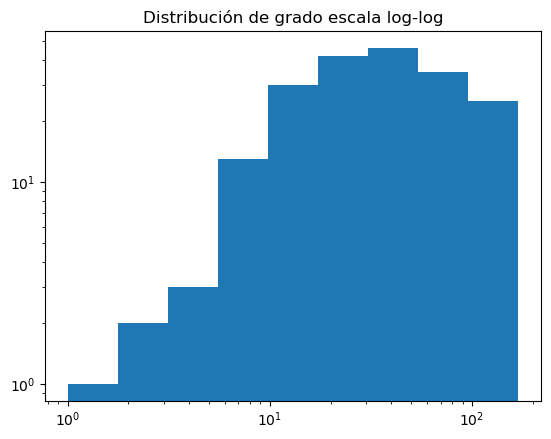

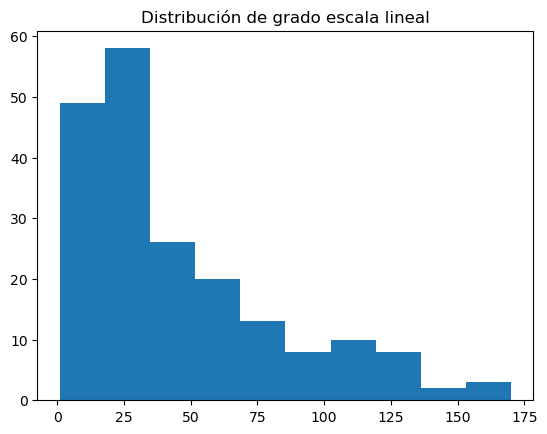

In [9]:
graph_description(G_afr)

## 3. Centralidades (al menos dos de las vistas en clase):

Centralidad de grado.

Centralidad de cercanía.

Centralidad de intermediación.

Centralidad de eigenvector, Katz o PageRank.

Deberán discutir cuáles son los ingredientes más importantes según cada centralidad
y si coinciden o no entre regiones.

In [10]:
def centralidades(G):
    c_deg = dict(nx.degree_centrality(G))
    c_bet = dict(nx.betweenness_centrality(G))
    c_cen = dict(nx.closeness_centrality(G))

    deg_df = pd.DataFrame({'Nodo': list(c_deg.keys()), 'Centralidad_Grado': list(c_deg.values())})
    bet_df = pd.DataFrame({'Nodo': list(c_bet.keys()), 'Centralidad_Betweenness': list(c_bet.values())})
    cen_df = pd.DataFrame({'Nodo': list(c_cen.keys()), 'Centralidad_Cercania': list(c_cen.values())})

    return [
        deg_df.sort_values(by='Centralidad_Grado', ascending=False),
        bet_df.sort_values(by='Centralidad_Betweenness', ascending=False),
        cen_df.sort_values(by='Centralidad_Cercania', ascending=False)
    ]

In [11]:

cen = centralidades(G_afr)
print('\nIngredientes mas importantes bajo la centralidad de Grado en Africa')
print(cen[0].head())

print('\nIngredientes mas importantes bajo la centralidad de intermediación en Africa')
print(cen[1].head())

print('\nIngredientes mas importantes bajo la centralidad de cercania en Africa')
print(cen[2].head())


Ingredientes mas importantes bajo la centralidad de Grado en Africa
         Nodo  Centralidad_Grado
3       onion           0.867347
7      garlic           0.811224
24  olive_oil           0.806122
25      wheat           0.744898
6       cumin           0.719388

Ingredientes mas importantes bajo la centralidad de intermediación en Africa
         Nodo  Centralidad_Betweenness
3       onion                 0.071371
24  olive_oil                 0.049882
7      garlic                 0.048696
25      wheat                 0.042492
13    cayenne                 0.032559

Ingredientes mas importantes bajo la centralidad de cercania en Africa
         Nodo  Centralidad_Cercania
3       onion              0.882883
7      garlic              0.837607
24  olive_oil              0.834043
25      wheat              0.796748
6       cumin              0.777778


## 4. Comunidades:

Detectar comunidades de ingredientes.

Calcular modularidad.

Interpretar los grupos encontrados.

Comparar las comunidades entre las dos regiones.

In [12]:
comunnities_afr = nx.community.louvain_communities(G_afr,seed = 42)
modularity =nx.community.modularity(G_afr, comunnities_afr)
print('Modularidad del grafo con las comunidades de louvain', modularity)

Modularidad del grafo con las comunidades de louvain 0.08443006231283348


In [13]:
#print('Comunidades que dio el algoritomo de louvain:\n')
comunnities_afr

[{'bay',
  'beef',
  'beef_broth',
  'coriander',
  'fenugreek',
  'kidney_bean',
  'meat',
  'parsnip',
  'pepper',
  'potato',
  'rutabaga',
  'sunflower_oil',
  'turmeric',
  'yam',
  'yogurt'},
 {'anise',
  'artichoke',
  'bean',
  'beet',
  'bell_pepper',
  'brown_rice',
  'caraway',
  'carrot',
  'cayenne',
  'celery',
  'chickpea',
  'cider',
  'cilantro',
  'cod',
  'condiment',
  'cucumber',
  'cumin',
  'dill',
  'fish',
  'garlic',
  'goat_cheese',
  'grape_juice',
  'green_bell_pepper',
  'haddock',
  'leek',
  'lemon',
  'lemon_juice',
  'lemon_peel',
  'lobster',
  'mint',
  'mussel',
  'olive',
  'olive_oil',
  'orange_peel',
  'parsley',
  'pimento',
  'prawn',
  'roasted_beef',
  'roasted_peanut',
  'roasted_sesame_seed',
  'rye_flour',
  'salmon',
  'seed',
  'shallot',
  'smoke',
  'thai_pepper',
  'tomato'},
 {'almond',
  'apple',
  'apricot',
  'banana',
  'barley',
  'bone_oil',
  'brandy',
  'bread',
  'butter',
  'cane_molasses',
  'cheese',
  'chive',
  'cocoa'

Escribir algo

## 6. Comparación con modelos aleatorios:

Comparar cada red real con una red Erdős–Rényi, mundo pequeño, barabassi,
con el mismo número de nodos y una densidad similar.

Comparar, si es posible, con un modelo que conserve aproximadamente la
distribución de grados.

Discutir si la red real parece tener estructura no aleatoria.
Discutir si la red presenta el efecto del mundo pequeño, libre de escale, etc.

In [14]:
def comparative(G):
    #Genero las metricas necesarias para obtener redes similares
    n = nx.number_of_nodes(G)
    m = nx.number_of_edges(G)
    grado_prom = 2*m/n
    seed = 42
    #Genero mi grafica de erdos
    p = ((m)*2)/(n*(n-1))
    E = nx.erdos_renyi_graph(n,p,seed= seed)

    #Genero mi grafica de watts-strogatz
    W = nx.watts_strogatz_graph(n,int(grado_prom), 0.05,seed= seed)

    #Genero mi grafica de albert
    A = nx.barabasi_albert_graph(n,int(grado_prom/2),seed= seed)

    #Ahora simplemente genero sus respectivas descripciones para comparar
    print("Descripción de la grafica Real\n")
    graph_description(G)
    print('\n')
    print("Descripcion de la grafica de Erdos-Renyi\n")
    graph_description(E)
    print('\n')
    print("Descripcion de la grafica de Watts-Strogatz\n")
    graph_description(W)
    print('\n')
    print("Descripción de la grafica de Albert-Barabasi\n")
    graph_description(A)
    

Descripción de la grafica Real

Numero de nodos: 197
Numero de aristas: 4468
Densidad: 0.23143064332331917
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 197
Porcentaje de la componente conexa 1.0
Grado promedio: 45.36040609137056
Coeficiente de clustering: 0.7757041314222881
Distancia promedio: 1.8012534963223867
Diametro: 4


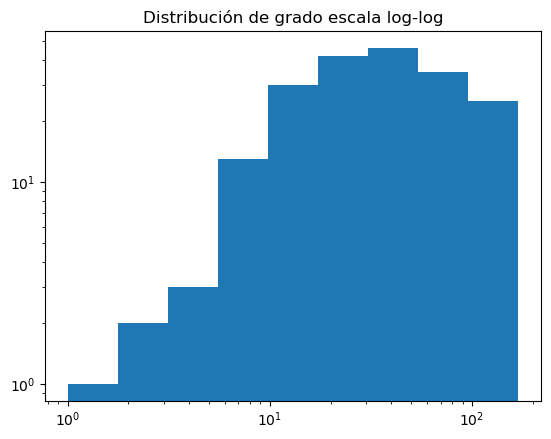

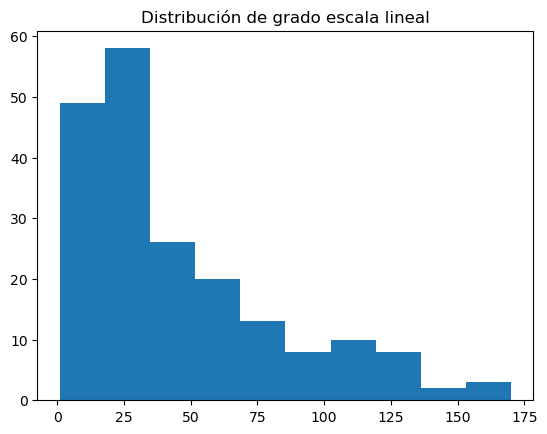



Descripcion de la grafica de Erdos-Renyi

Numero de nodos: 197
Numero de aristas: 4481
Densidad: 0.23210400911633688
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 197
Porcentaje de la componente conexa 1.0
Grado promedio: 45.49238578680203
Coeficiente de clustering: 0.23355618081878274
Distancia promedio: 1.7678959908836631
Diametro: 2


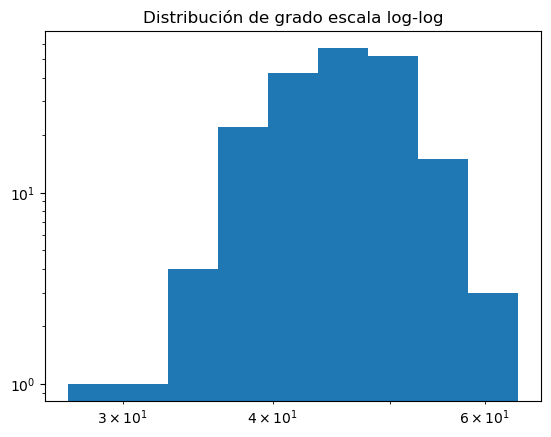

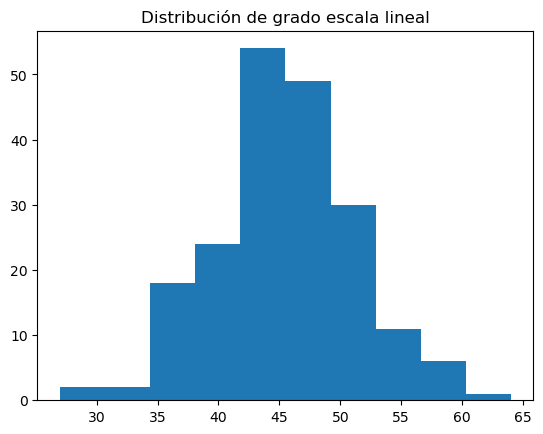



Descripcion de la grafica de Watts-Strogatz

Numero de nodos: 197
Numero de aristas: 4334
Densidad: 0.22448979591836735
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 197
Porcentaje de la componente conexa 1.0
Grado promedio: 44.0
Coeficiente de clustering: 0.645232177994679
Distancia promedio: 1.9420905418004766
Diametro: 3


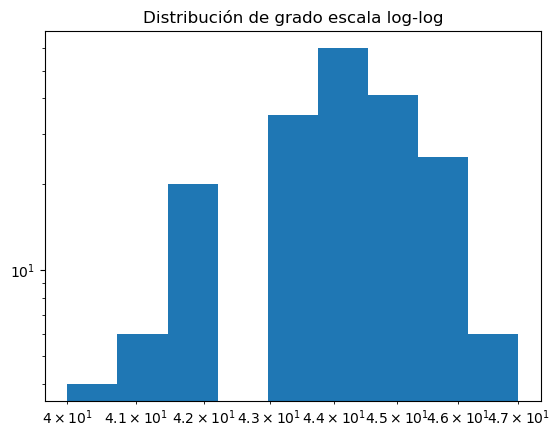

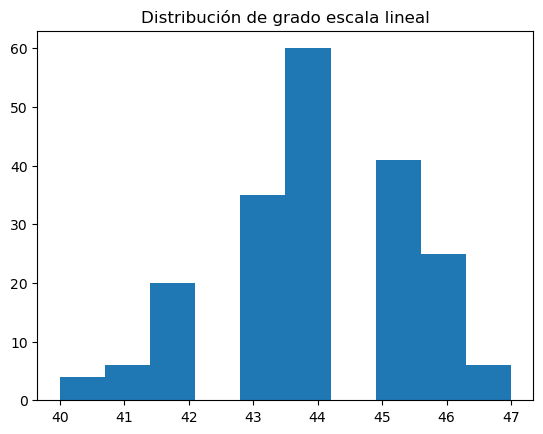



Descripción de la grafica de Albert-Barabasi

Numero de nodos: 197
Numero de aristas: 3850
Densidad: 0.1994198694706309
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 197
Porcentaje de la componente conexa 1.0
Grado promedio: 39.08629441624365
Coeficiente de clustering: 0.2982160016795377
Distancia promedio: 1.8026002279084223
Diametro: 3


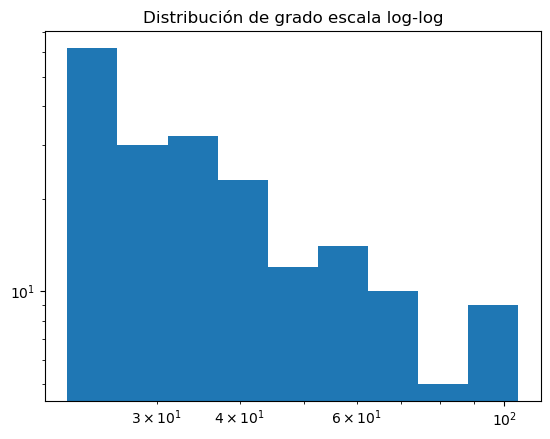

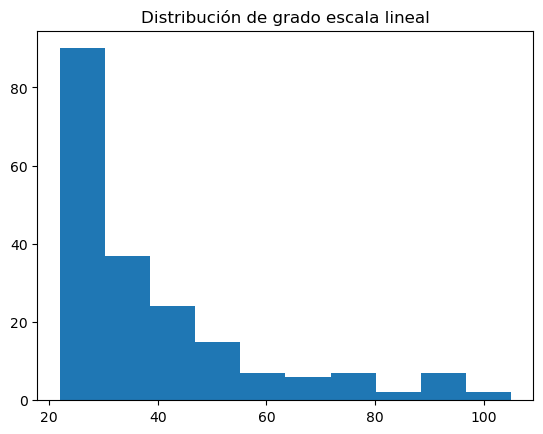

In [15]:
comparative(G_afr)

Al comprobar las variables numericas parece ser que los grafos son bastante similares entre si, pero al ver las graficas tanto en escala log, log como en escala lineal parece que si existen diferencias sustanciales entre las graficas, viendo sobretodo que parece ser que la grafica real no se parece mucho a las otras, sin embrago existe precencia de muchos hubs, lo cual se puede ver que tiene cierto parecido con el modelo de albert barabasi y poco de red aleatoria.

## 7. Visualización:

Graficar las redes o una subred representativa.

Mostrar los ingredientes más importantes.

Visualizar comunidades.

Incluir gráficas comparativas entre regiones.

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

def graficar_grafo_louvain(G):
    #Centralidad
    centralidad = nx.closeness_centrality(G)
    top5 = sorted(centralidad, key = centralidad.get, reverse = True)[:5]

    #Comunidades
    comunidades = nx.community.louvain_communities(G, seed = 42)
    particion = {}
    for idx, comunidad in enumerate(comunidades):
        for nodo in comunidad:
            particion[nodo] = idx
    #Obtengo el numero de comunidades
    num_comunidades = len(comunidades)
    #Hago mapeo de colores
    cmap = plt.cm.get_cmap("tab10", num_comunidades)
    #Asigno e color a cada nodo
    node_colors = [cmap(particion[n]) for n in G.nodes()]

    #Tamaño del nodo
    node_sizes = [
        800 + centralidad[n] * 1500 if n in top5 else 200 + centralidad[n] * 300
        for n in G.nodes()
    ]
    
    #Creacion de la grafica
    pos = nx.spring_layout(G, k=10,seed=42)

    plt.figure(figsize=(12, 8))
    nx.draw_networkx(G,with_labels = True, node_size = node_sizes,node_color = node_colors)

    

/tmp/ipykernel_20980/361562678.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_comunidades)


Text(0.5, 1.0, 'Grafica de ingredientes de Africa')

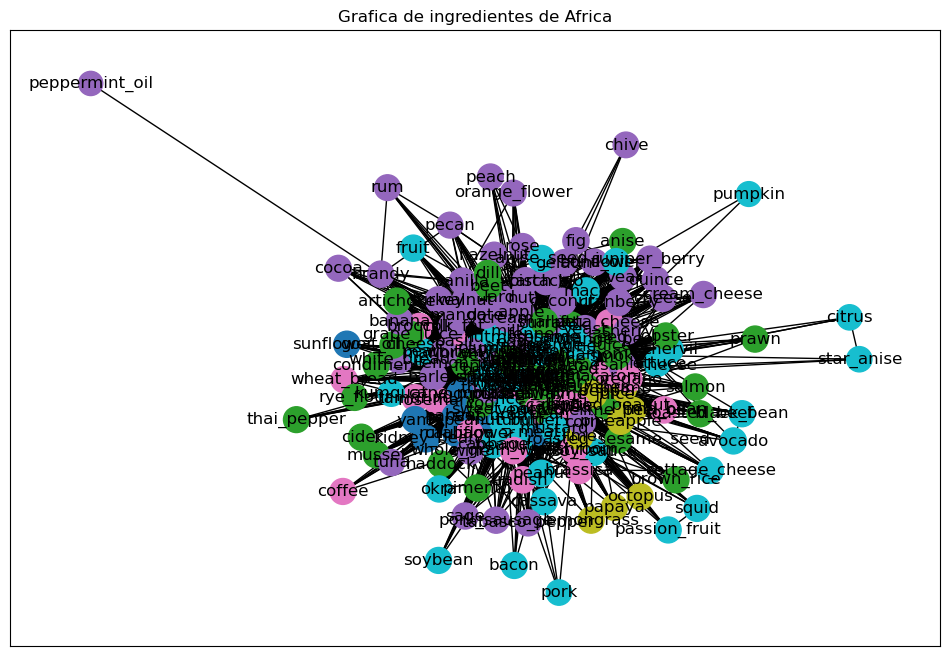

In [35]:
graficar_grafo_louvain(G_afr)
plt.title('Grafica de ingredientes de Africa')

# Region de LATAM

In [18]:
df_lat = df[df[0] == 'LatinAmerican']
df_lat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
3245,LatinAmerican,tomato,cilantro,lemon_juice,onion,green_bell_pepper,cayenne,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3246,LatinAmerican,olive_oil,pepper,lemon_juice,wheat,onion,vinegar,asparagus,parsley,white_wine,...,None,None,None,None,None,None,None,None,None,None
3247,LatinAmerican,tomato,pepper,potato,lime_juice,cayenne,cumin,scallion,cilantro,cream,...,None,None,None,None,None,None,None,None,None,None
3248,LatinAmerican,tomato,beef,onion,cayenne,corn,black_pepper,cumin,buttermilk,bean,...,None,None,None,None,None,None,None,None,None,None
3249,LatinAmerican,tomato,garlic,onion,beef,cayenne,cumin,bell_pepper,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6157,LatinAmerican,tomato,pepper,ham,onion,black_bean,cayenne,cilantro,mango,garlic,...,None,None,None,None,None,None,None,None,None,None
6158,LatinAmerican,vanilla,mango,milk,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
6159,LatinAmerican,vinegar,cilantro,lemon_juice,cayenne,scallion,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
6160,LatinAmerican,tomato,celery,pepper,onion,beef,honey,garlic,cheddar_cheese,brown_rice,...,None,None,None,None,None,None,None,None,None,None


In [19]:
G_lat = df_to_graph(df_lat)

## 1. Descripción general de los datos:

Número de recetas por región.

Número de ingredientes distintos.

Tamaño promedio de las recetas.

Ingredientes más frecuentes por región.

In [20]:
general_description(df_lat,G_lat)

Numero de Recetas: 2917
Numero de ingredientes distintos: 260
Tamaño promedio de las recetas: 9.379499485773055
Ingredientes mas frecuentes por region: ['cayenne', 'onion', 'garlic', 'tomato', 'corn']


## 2. Propiedades básicas de las redes:
 
Número de nodos y aristas.

Densidad.

Componentes conexas.

Tamaño de la componente gigante.

Grado promedio.

Distribución de grados.

Coeficiente de clustering.

Distancia promedio y diámetro, si la red lo permite.

Numero de nodos: 260
Numero de aristas: 9405
Densidad: 0.2793287793287793
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 260
Porcentaje de la componente conexa 1.0
Grado promedio: 72.34615384615384
Coeficiente de clustering: 0.7870063220112153
Distancia promedio: 1.7357885357885359
Diametro: 3


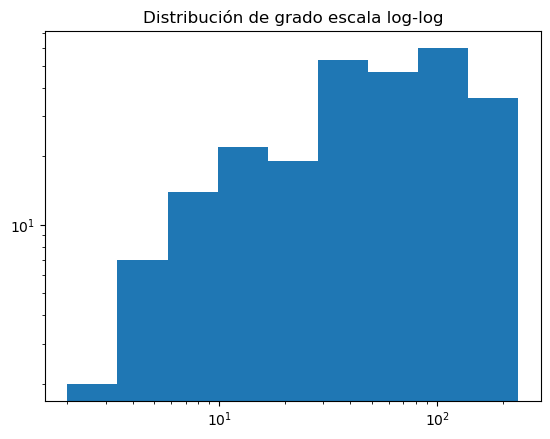

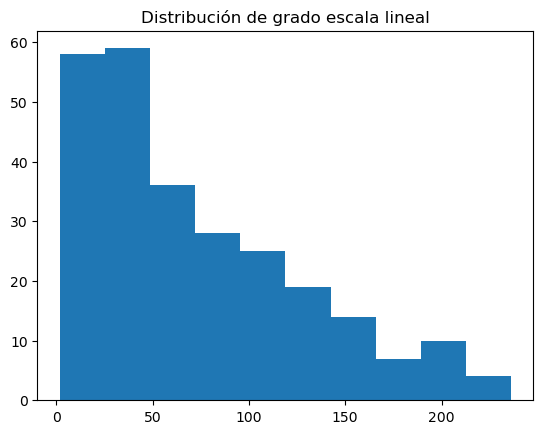

In [21]:
graph_description(G_lat)

## 3. Centralidades (al menos dos de las vistas en clase):
Centralidad de grado.

Centralidad de cercanía.

Centralidad de intermediación.

Centralidad de eigenvector, Katz o PageRank.

Deberán discutir cuáles son los ingredientes más importantes según cada centralidad y si coinciden o no entre regiones.

In [22]:
cen = centralidades(G_lat)
print('\nIngredientes mas importantes bajo la centralidad de Grado en Latam')
print(cen[0].head())

print('\nIngredientes mas importantes bajo la centralidad de intermediación en Latam')
print(cen[1].head())

print('\nIngredientes mas importantes bajo la centralidad de cercania en Latam')
print(cen[2].head())


Ingredientes mas importantes bajo la centralidad de Grado en Latam
             Nodo  Centralidad_Grado
3           onion           0.911197
13         garlic           0.895753
5         cayenne           0.884170
0          tomato           0.857143
17  vegetable_oil           0.772201

Ingredientes mas importantes bajo la centralidad de intermediación en Latam
       Nodo  Centralidad_Betweenness
3     onion                 0.045237
13   garlic                 0.041314
5   cayenne                 0.040243
0    tomato                 0.032007
8     wheat                 0.027381

Ingredientes mas importantes bajo la centralidad de cercania en Latam
             Nodo  Centralidad_Cercania
3           onion              0.918440
13         garlic              0.905594
5         cayenne              0.896194
0          tomato              0.875000
17  vegetable_oil              0.814465


## 4. Comunidades:

Detectar comunidades de ingredientes.

Calcular modularidad.

Interpretar los grupos encontrados.

Comparar las comunidades entre las dos regiones.

In [29]:
comunnities_lat = nx.community.louvain_communities(G_lat,seed = 42)
modularity =nx.community.modularity(G_lat, comunnities_lat)
print('Modularidad del grafo con las comunidades de louvain', modularity)
comunnities_lat

Modularidad del grafo con las comunidades de louvain 0.07800558178841996


[{'artichoke',
  'baked_potato',
  'barley',
  'bean',
  'beef',
  'bell_pepper',
  'black_bean',
  'black_pepper',
  'broccoli',
  'brown_rice',
  'buttermilk',
  'cayenne',
  'cereal',
  'cheddar_cheese',
  'cheese',
  'chicken',
  'chicken_broth',
  'chickpea',
  'corn',
  'corn_flake',
  'corn_grit',
  'cottage_cheese',
  'cream',
  'cream_cheese',
  'cumin',
  'egg_noodle',
  'garlic',
  'green_bell_pepper',
  'kidney_bean',
  'lard',
  'lettuce',
  'macaroni',
  'munster_cheese',
  'mushroom',
  'olive',
  'onion',
  'oregano',
  'porcini',
  'pork_sausage',
  'rice',
  'roasted_meat',
  'roasted_pork',
  'romano_cheese',
  'sauerkraut',
  'scallion',
  'smoked_sausage',
  'thai_pepper',
  'tomato',
  'turkey',
  'vegetable_oil',
  'whole_grain_wheat_flour'},
 {'avocado',
  'beer',
  'blueberry',
  'cassava',
  'chicory',
  'cilantro',
  'clam',
  'cod',
  'cucumber',
  'endive',
  'feta_cheese',
  'fish',
  'gin',
  'goat_cheese',
  'grape_juice',
  'grapefruit',
  'haddock',
  

## 6. Comparación con modelos aleatorios:

Comparar cada red real con una red Erdős–Rényi, mundo pequeño, barabassi,
con el mismo número de nodos y una densidad similar.

Comparar, si es posible, con un modelo que conserve aproximadamente la
distribución de grados.

Discutir si la red real parece tener estructura no aleatoria.
Discutir si la red presenta el efecto del mundo pequeño, libre de escale, etc.

Descripción de la grafica Real

Numero de nodos: 260
Numero de aristas: 9405
Densidad: 0.2793287793287793
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 260
Porcentaje de la componente conexa 1.0
Grado promedio: 72.34615384615384
Coeficiente de clustering: 0.7870063220112153
Distancia promedio: 1.7357885357885359
Diametro: 3


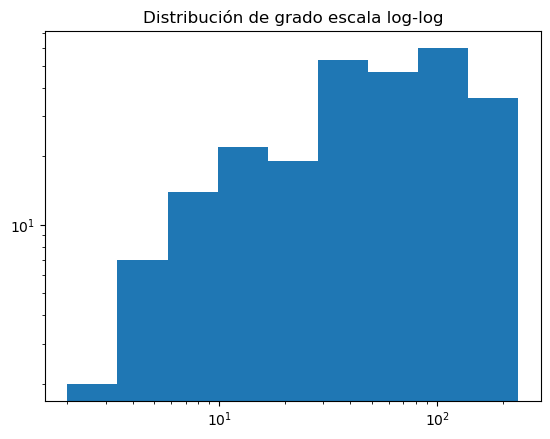

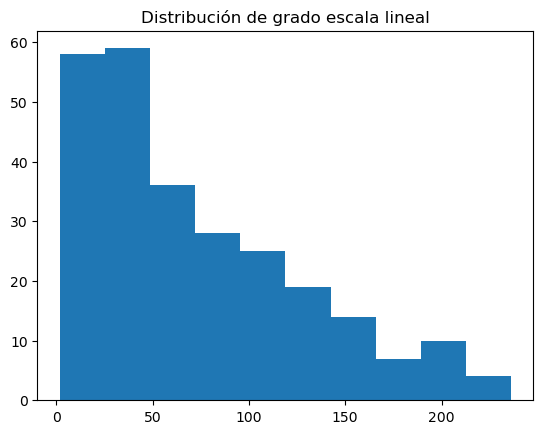



Descripcion de la grafica de Erdos-Renyi

Numero de nodos: 260
Numero de aristas: 9376
Densidad: 0.2784674784674785
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 260
Porcentaje de la componente conexa 1.0
Grado promedio: 72.12307692307692
Coeficiente de clustering: 0.2796967981541729
Distancia promedio: 1.7215325215325215
Diametro: 2


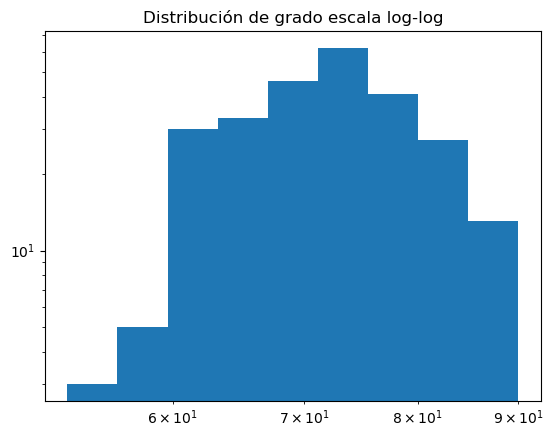

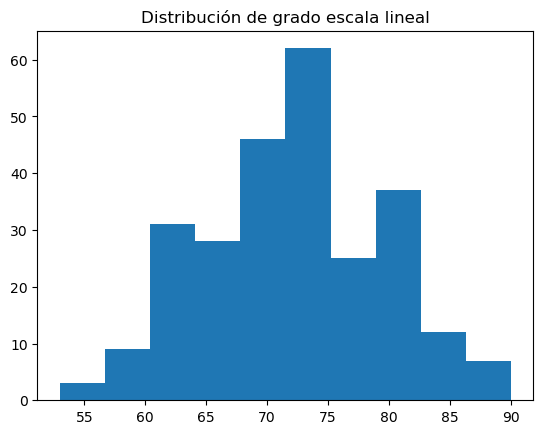



Descripcion de la grafica de Watts-Strogatz

Numero de nodos: 260
Numero de aristas: 9360
Densidad: 0.277992277992278
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 260
Porcentaje de la componente conexa 1.0
Grado promedio: 72.0
Coeficiente de clustering: 0.653075645198522
Distancia promedio: 1.7467181467181467
Diametro: 3


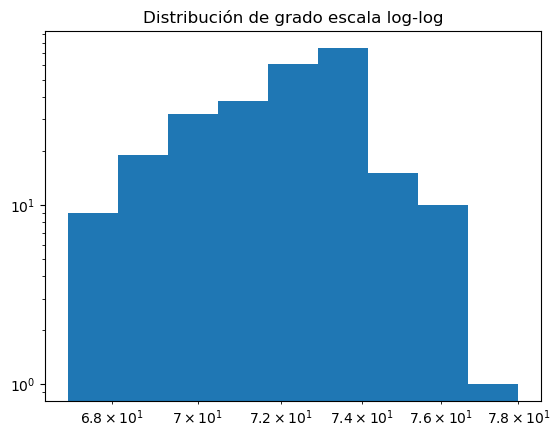

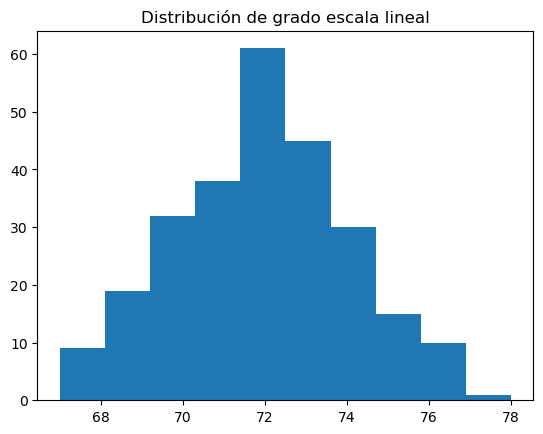



Descripción de la grafica de Albert-Barabasi

Numero de nodos: 260
Numero de aristas: 8064
Densidad: 0.23950103950103951
Numero de componentes conexas: 1
Tamaño de la componente gigantes: 260
Porcentaje de la componente conexa 1.0
Grado promedio: 62.03076923076923
Coeficiente de clustering: 0.3342513844448953
Distancia promedio: 1.7605286605286605
Diametro: 3


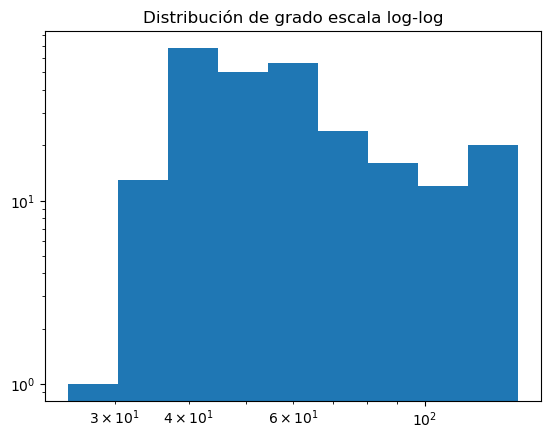

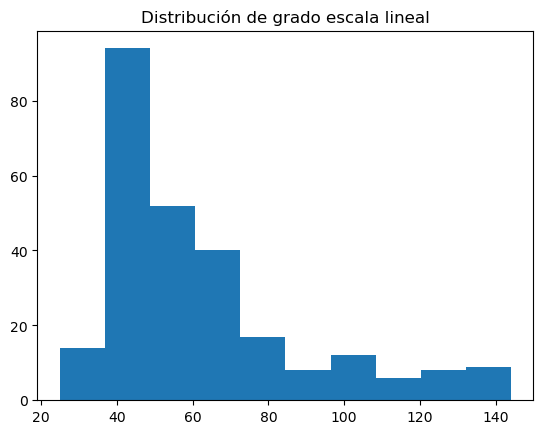

In [24]:
comparative(G_lat)

En comparacion con la redes aleatorias la redes parecen bastante similares en basicamente todas las metricas, en lo que si difieren bastante es en la distribución de grados, sin embargo existe cierta similitud entre la distribución real y la de albert-barabasi, ya que existen bastante nodos muy bien conectados

## 7. Visualización:

Graficar las redes o una subred representativa.

Mostrar los ingredientes más importantes.

Visualizar comunidades.

Incluir gráficas comparativas entre regiones.

/tmp/ipykernel_20980/361562678.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_comunidades)


Text(0.5, 1.0, 'Visualización de la grafica de ingredientes de latam')

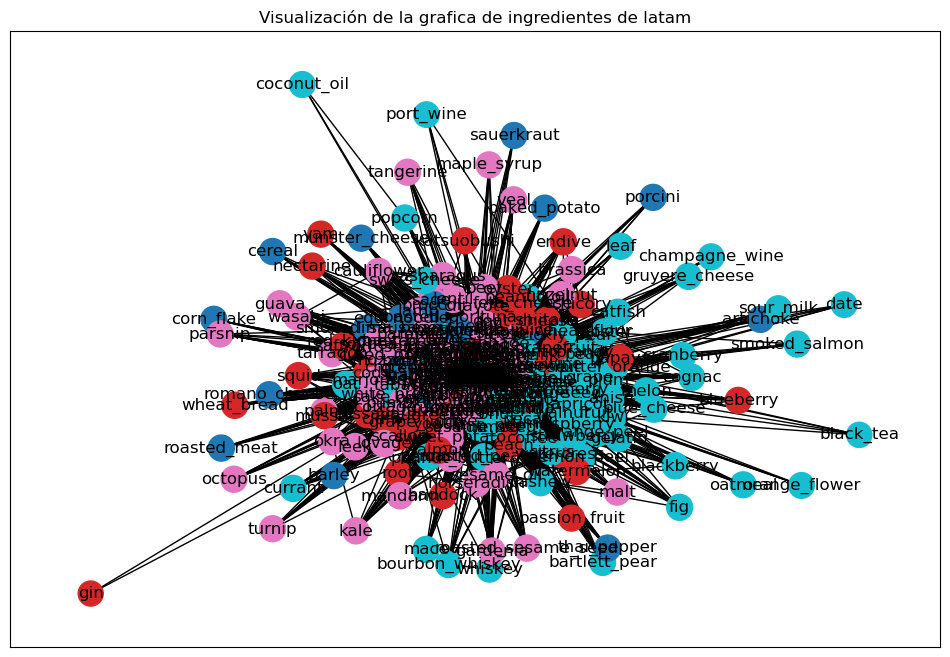

In [36]:
graficar_grafo_louvain(G_lat)
plt.title("Visualización de la grafica de ingredientes de latam")

# 5. Comparación entre regiones:

Ingredientes compartidos entre ambas regiones.

Ingredientes característicos de cada región.

Pares de ingredientes frecuentes.

Diferencias en estructura: densidad, clustering, centralidades, comunidades, etc.

In [26]:
def comparacion_reg(G1,G2):
    #Nodos compartidos
    nodos_comp = []
    for node in G1.nodes():
        if node in G2.nodes():
            nodos_comp.append(node)
    
    #Ingredientes caracteristicos de cada region (voy a tomar el top5 de los que tienen mayor grado)
    centralidadG1 = nx.degree_centrality(G1)
    top5G1 = sorted(centralidadG1, key = centralidadG1.get, reverse = True)[:5]

    centralidadG2 = nx.degree_centrality(G2)
    top5G2 = sorted(centralidadG2, key = centralidadG2.get, reverse = True)[:5]

    #Ver pares de nodos mas frecuentes
    atrg1 =nx.get_edge_attributes(G1, 'weight')
    toppar1 = sorted(atrg1.items(), key=lambda x: x[1], reverse=True)[:5]

    atrg2 =nx.get_edge_attributes(G2, 'weight')
    toppar2 = sorted(atrg2.items(), key=lambda x: x[1], reverse=True)[:5]

    #Comparacion de densidad, clustering, centralidades.
    print("Densidad del Primer Grafo:", nx.density(G1))
    print("Densidad del segundo Grafo:", nx.density(G2))
    print('\n')
    print("Clustering promedio del primer Grafo", nx.average_clustering(G1))
    print("Clustering promedio del segundo Grafo", nx.average_clustering(G2))
    print('\n')
    print("Tamaño de distancia promedio del primer Grafo:",nx.average_shortest_path_length(G1))
    print("Tamaño de distancia promedio del segundo Grafo:", nx.average_shortest_path_length(G2))
    print('\n')
    print("Pares de nodos mas frecuentes del primer Grafo:", toppar1)
    print("Pares de nodos mas frecuentes del segundo Grafo:", toppar2)
    print('\n')
    print("Ingredientes caracteristicos del primer Grafo:",top5G1)
    print("Ingredientes caracteristicos del segundo Grafo",top5G2)
    print('\n')
    print("Ingredientes Compratidos:")
    print(nodos_comp)

In [27]:
comparacion_reg(G_afr,G_lat)

Densidad del Primer Grafo: 0.23143064332331917
Densidad del segundo Grafo: 0.2793287793287793


Clustering promedio del primer Grafo 0.7757041314222881
Clustering promedio del segundo Grafo 0.7870063220112153


Tamaño de distancia promedio del primer Grafo: 1.8012534963223867
Tamaño de distancia promedio del segundo Grafo: 1.7357885357885359


Pares de nodos mas frecuentes del primer Grafo: [(('cumin', 'olive_oil'), 121), (('garlic', 'olive_oil'), 107), (('onion', 'olive_oil'), 101), (('onion', 'cumin'), 97), (('onion', 'garlic'), 96)]
Pares de nodos mas frecuentes del segundo Grafo: [(('onion', 'cayenne'), 1496), (('onion', 'garlic'), 1456), (('cayenne', 'garlic'), 1413), (('tomato', 'onion'), 1338), (('tomato', 'cayenne'), 1278)]


Ingredientes caracteristicos del primer Grafo: ['onion', 'garlic', 'olive_oil', 'wheat', 'cumin']
Ingredientes caracteristicos del segundo Grafo ['onion', 'garlic', 'cayenne', 'tomato', 'vegetable_oil']


Ingredientes Compratidos:
['chicken', 'cinnamon', '

In [30]:
l = ['chicken', 'cinnamon', 'soy_sauce', 'onion', 'ginger', 'cane_molasses', 'cumin', 'garlic', 'tamarind', 'bread', 'coriander', 'vinegar', 'beef', 'cayenne', 'parsley', 'wheat_bread', 'yogurt', 'vegetable_oil', 'egg', 'butter', 'pepper', 'cottage_cheese', 'brassica', 'olive_oil', 'wheat', 'rice', 'leek', 'honey', 'yeast', 'tomato', 'cilantro', 'lemon_juice', 'scallion', 'cassava', 'potato', 'black_pepper', 'carrot', 'cabbage', 'turmeric', 'fenugreek', 'coconut', 'pumpkin', 'lamb', 'bay', 'fennel', 'zucchini', 'beef_broth', 'bell_pepper', 'meat', 'apricot', 'basil', 'starch', 'vanilla', 'milk', 'olive', 'red_wine', 'cod', 'raisin', 'almond', 'white_bread', 'vegetable', 'brown_rice', 'peanut_butter', 'bean', 'nutmeg', 'rosemary', 'chicken_broth', 'green_bell_pepper', 'chickpea', 'roasted_peanut', 'sweet_potato', 'thyme', 'mushroom', 'peanut_oil', 'seed', 'shrimp', 'pear', 'parsnip', 'celery', 'fish', 'date', 'lard', 'lentil', 'walnut', 'macaroni', 'lemon', 'roasted_sesame_seed', 'cucumber', 'mint', 'plum', 'turnip', 'mustard', 'salmon', 'lime_juice', 'lime', 'saffron', 'parmesan_cheese', 'pea', 'orange_juice', 'feta_cheese', 'thai_pepper', 'cheese', 'cauliflower', 'broccoli', 'oregano', 'squash', 'orange_flower', 'nut', 'corn', 'cream', 'peach', 'whole_grain_wheat_flour', 'cream_cheese', 'sesame_seed', 'anise', 'goat_cheese', 'radish', 'orange', 'cranberry', 'kidney_bean', 'pimento', 'hazelnut', 'pecan', 'smoke', 'apple', 'milk_fat', 'mace', 'anise_seed', 'white_wine', 'grape_juice', 'currant', 'orange_peel', 'wine', 'soybean', 'gelatin', 'brandy', 'haddock', 'sherry', 'roasted_beef', 'lima_bean', 'fruit', 'barley', 'lemon_peel', 'shallot', 'beet', 'pineapple', 'banana', 'lime_peel_oil', 'cocoa', 'yam', 'veal', 'fig', 'dill', 'marjoram', 'turkey', 'coffee', 'cider', 'mussel', 'chive', 'artichoke', 'lobster', 'okra', 'citrus', 'pork', 'peanut', 'papaya', 'octopus', 'rum', 'lettuce', 'sage', 'tabasco_pepper', 'pork_sausage', 'passion_fruit', 'squid', 'black_bean', 'avocado', 'mango', 'tuna', 'bacon']
len(l)

179